Missing Values per Column:
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64
DataFrame with new features:
             Date        Time State     Group  Unit  Sales  Log_Sales  \
0      1-Oct-2020     Morning    WA      Kids     8  20000   9.903538   
1      1-Oct-2020     Morning    WA       Men     8  20000   9.903538   
2      1-Oct-2020     Morning    WA     Women     4  10000   9.210440   
3      1-Oct-2020     Morning    WA   Seniors    15  37500  10.532123   
4      1-Oct-2020   Afternoon    WA      Kids     3   7500   8.922792   
...           ...         ...   ...       ...   ...    ...        ...   
7555  30-Dec-2020   Afternoon   TAS   Seniors    14  35000  10.463132   
7556  30-Dec-2020     Evening   TAS      Kids    15  37500  10.532123   
7557  30-Dec-2020     Evening   TAS       Men    15  37500  10.532123   
7558  30-Dec-2020     Evening   TAS     Women    11  27500  10.221978   
7559  30-Dec-2020     Evening   TAS   Seniors    13  32500  10

Sales                                                   \
               mean   median    min     max        sum           std   
State                                                                  
 NSW   69416.666667  70000.0  30000  112500   74970000  20626.651646   
 NT    20907.407407  20000.0   5000   37500   22580000   8961.907893   
 QLD   30942.129630  30000.0   7500   62500   33417500  13344.638002   
 SA    54497.685185  52500.0  25000   87500   58857500  17460.965183   
 TAS   21074.074074  20000.0   5000   37500   22760000   9024.684205   
 VIC   97745.370370  95000.0  50000  162500  105565000  26621.597092   
 WA    20511.574074  20000.0   5000   37500   22152500   9231.905897   

                           
                var count  
State                      
 NSW   4.254588e+08  1080  
 NT    8.031579e+07  1080  
 QLD   1.780794e+08  1080  
 SA    3.048853e+08  1080  
 TAS   8.144492e+07  1080  
 VIC   7.087094e+08  1080  
 WA    8.522809e+07  1080

                 Sales       Unit
mean      45013.558201  18.005423
median    35000.000000  14.000000
std       32253.506944  12.901403
<lambda>  22500.000000   9.000000
Highest Sales Group:  Men with 85750000
Lowest Sales Group:  Seniors with 84037500
------------ Weekly Sales Report ----------
Week
40    15045000
41    27002500
42    26640000
43    26815000
44    21807500
45    20865000
46    21172500
47    21112500
48    21477500
49    29622500
50    31525000
51    31655000
52    31770000
53    13792500
Name: Sales, dtype: int64
------------ Monthly Sales Report ----------
Month
10    114290000
11     90682500
12    135330000
Name: Sales, dtype: int64
------------ Quarterly Sales Report ----------
Quarter
4    340302500
Name: Sales, dtype: int64


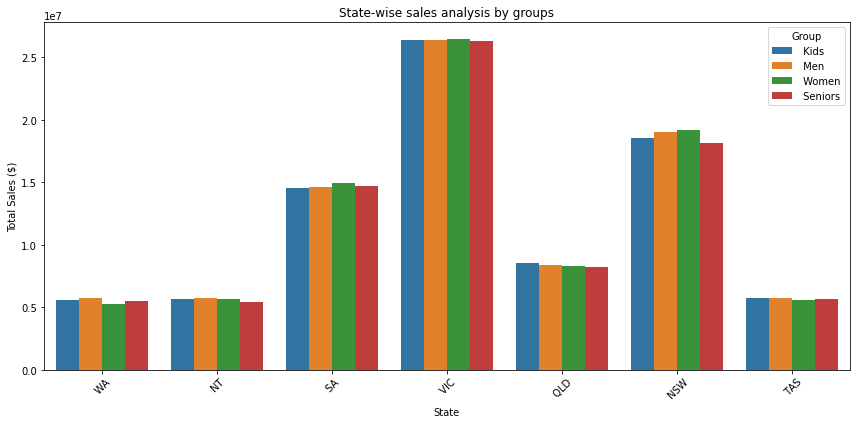

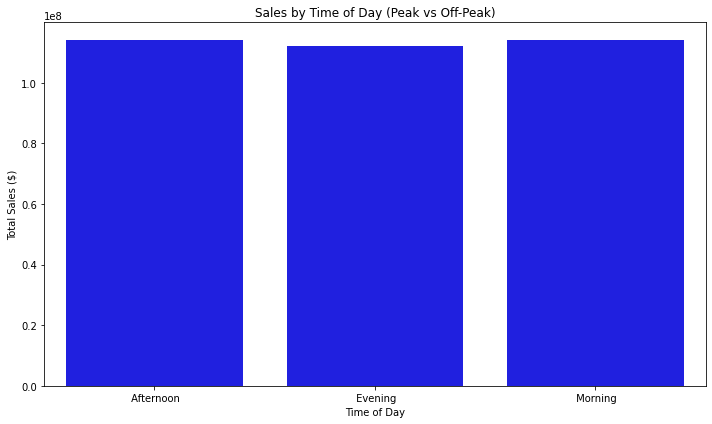

Peak Sales Time:  Morning
Off-Peak Sales Period:  Evening


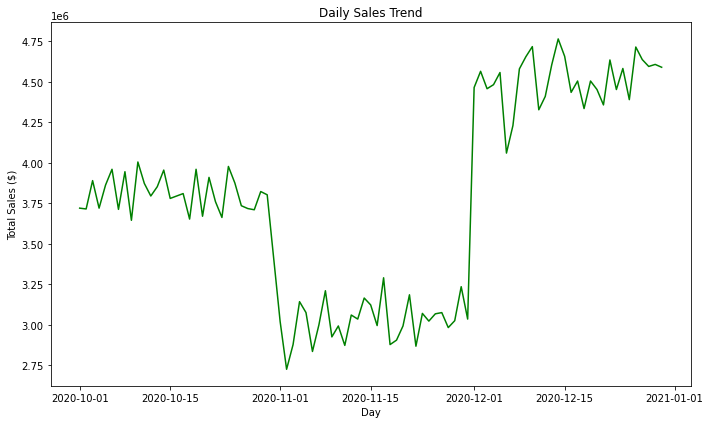

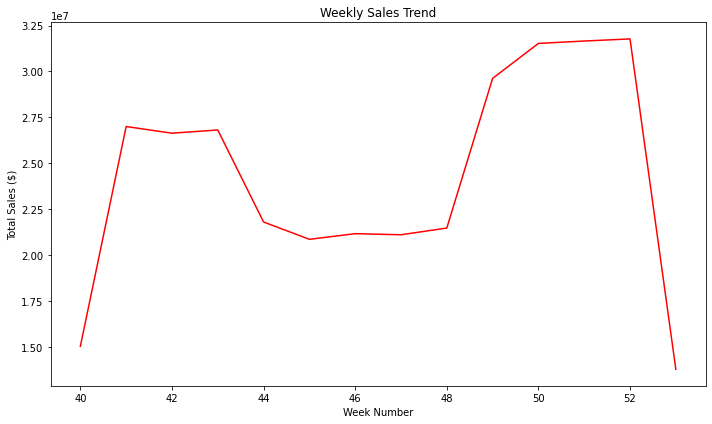

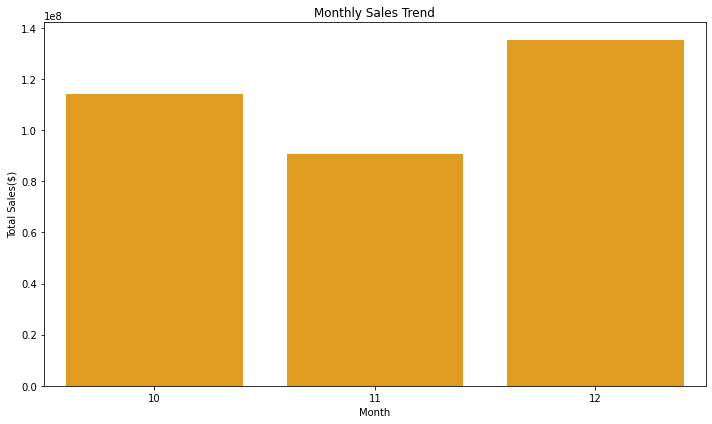

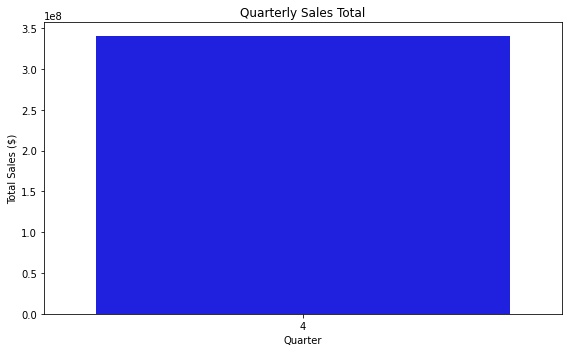

In [ ]:
#Data Wrangling Part 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load the data
df = pd.read_csv('AusSales.csv')

df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Unit'] = pd.to_numeric(df['Unit'], errors='coerce')

# Checking for missing values
missing_values = df.isnull().sum()
print("Missing Values per Column:")
print(missing_values)

if 'Sales' in df.columns:
    # Use the natural logarithm to create a new feature 'Log_Sales'
    df['Log_Sales'] = df['Sales'].apply(lambda x: np.log1p(x))
    
    # Normalize 'sales' column and create a new feature 'Normalized_Sales'
    df['Normalized_Sales'] = (df['Sales'] - df['Sales'].min()) / (df['Sales'].max() - df['Sales'].min())

    # Displaying the DataFrame with the new features
    print("DataFrame with new features:")
    print(df)
    
    
# Grouping the DataFrame by 'Category' and calculating various aggregations
df_aggregated = df.groupby('State').agg({
    'Sales': ['mean', 'median', 'min', 'max', 'sum', 'std', 'var', 'count']
})

# Displaying the aggregated DataFrame
print("Aggregated DataFrame:")
display(df_aggregated)

# Calculate mean, median, and standard deviation
target_columns = ['Sales', 'Unit']

descrip_stat = df[target_columns].agg(['mean', 'median', 'std', lambda x: x.mode().iloc[0]])

print(descrip_stat)
 
#Identify highest and lowest sales
group_sum = df.groupby('Group')['Sales'].sum()

highest_sale = group_sum.idxmax()
highest_value = group_sum.max()

lowest_sale = group_sum.idxmin()
lowest_value = group_sum.min()

print(f"Highest Sales Group: {highest_sale} with {highest_value}")
print(f"Lowest Sales Group: {lowest_sale} with {lowest_value}")

#Create weekly/monthly/quarterly reports

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df=df.dropna(subset=['Date'])

df['Week'] = df['Date'].dt.isocalendar().week
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

weekly_report = df.groupby('Week')['Sales'].sum()
monthly_report = df.groupby('Month')['Sales'].sum()
quarterly_report = df.groupby('Quarter')['Sales'].sum()

print("------------ Weekly Sales Report ----------")

print(weekly_report)

print("------------ Monthly Sales Report ----------")

print(monthly_report)

print("------------ Quarterly Sales Report ----------")

print(quarterly_report)

#Data visulisation

plt.figure(figsize=(12,6))

sns.barplot(data=df, x='State', y='Sales', hue='Group', estimator=sum, errorbar=None)

plt.xlabel('State')
plt.ylabel('Total Sales ($)')
plt.title('State-wise sales analysis by groups')
                  
plt.legend(title='Group')
        
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

time_sales = df.groupby('Time')['Sales'].sum().reset_index()


peak_time = time_sales.loc[time_sales['Sales'].idxmax(), 'Time']
off_peak_time = time_sales.loc[time_sales['Sales'].idxmin(), 'Time']

plt.figure(figsize=(10,6))
sns.barplot(data=time_sales, x='Time', y='Sales', color='blue')
plt.title('Sales by Time of Day (Peak vs Off-Peak)')
plt.xlabel('Time of Day')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()    
    

print(f"Peak Sales Time: {peak_time}")
print(f"Off-Peak Sales Period: {off_peak_time}")    
    

df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df = df.dropna(subset=['Sales'])

df['Week'] = df['Week'].astype(int)
df['Month'] = df['Month'].astype(int)
df['Quarter'] = df['Quarter'].astype(int)

#Daily chart
df['Day'] = df['Date'].dt.date
daily_sales = df.groupby('Day')['Sales'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=daily_sales, x='Day', y='Sales', color='green')
plt.title('Daily Sales Trend')
plt.xlabel('Day')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show() 

#Weekly
weekly_sales = df.groupby('Week')['Sales'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=weekly_sales, x='Week', y='Sales', color='red')
plt.title('Weekly Sales Trend')
plt.xlabel('Week Number')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show() 

#Monthy
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=monthly_sales, x='Month', y='Sales', color='orange', errorbar=None)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales($)')
plt.tight_layout()
plt.show() 

#Quarterly
quarterly_sales = df.groupby('Quarter')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=quarterly_sales, x='Quarter',y='Sales', color='blue', errorbar=None)
plt.title('Quarterly Sales Total')
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()



## GroupBy() Insight

In this project, the GroupBy() function was mainly used for data chunking, meaning the dataset was grouped into business categories such as State, Group (Kids, Men, Women, Seniors), and Time of Day. 

This allowed large transaction-level data to be summarized into meaningful totals, such as:
- Total sales by State
- Total sales by demographic Group
- Total sales by Time of Day

GroupBy() can also be used for merging, where summary results are joined back to the original dataset for deeper analysis. However, since this project focuses on reporting and dashboards, chunking was the most appropriate use.


Recommendation: For this project, GroupBy() for chunking is the best approach, because the main goal is executive reporting and dashboard creation


## Visualization Package Recommendation

Seaborn is the recommended visualization package for this project. It was chosen because it creates clear, professional, and easy-to-read statistical visualizations. 

Seaborn supports the required charts for this analysis, including bar plots, line plots, box plots, and distribution plots. These visualizations help the Sales & Marketing team quickly identify high-performing states, compare demographic groups, and understand daily, weekly, monthly, and quarterly sales trends.


# AAL Sales Analysis (Australia Q4) 

This report is an analysis on AAL Q4 sales data reviewing states in Australia and demoestic groups to support a data driven descision by the Sales and Marketing team. 

The dataset used for this analysis have key coulmns including: States, Groups, Time of Day, Sales, Units, and Date.

Missing values were inspected using isnull(). Numeric fields were converted to numeric types, invalid dates were removed, and Sales values were normilized using Min-Max normalization. 

Descriptive statistical analysis were computed for Sales and Unit columns. The following visulizations show sales trends and decision making by the Sales and Marketing team

Sebron was used to create bar charts, line plots, box plots, and discription plots, making it ideal for business dashboards. 
